### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from shapely.geometry import Point
from pyproj import Transformer

In [2]:
base_path = "/mnt/raid/emotional_data_raquel/fulldata_mine"

___________

## Check cum_dist quality

In [3]:
results = []

for root, dirs, files in os.walk(base_path):
    if "alldata.csv" in files:
        file_path = os.path.join(root, "alldata.csv")
        
        parts = root.split(os.sep)
        
        try:
            sub = [p for p in parts if p.startswith("sub-")][0]
        except:
            sub = "unknown_sub"
            
        try:
            ses = [p for p in parts if p.startswith("ses-")][0]
        except:
            ses = "unknown_ses"
        
        # Clean session name (important for grouping)
        session_clean = ses.replace("ses-", "").replace("ses_", "")
        
        label = f"{sub} | {session_clean}"
        
        try:
            df = pd.read_csv(file_path)
            
            has_column = "cum_dist" in df.columns
            
            if has_column:
                non_null = df["cum_dist"].notna().sum()
                has_values = non_null > 0
                percent_valid = (non_null / len(df)) * 100
            else:
                has_values = False
                percent_valid = 0
            
            results.append({
                #"participant_session": label,
                "participant": sub,
                "session": session_clean,
                "has_cum_dist_column": has_column,
                "has_values": has_values,
                "valid_%": round(percent_valid, 2)
            })
        
        except Exception as e:
            results.append({
                #"participant_session": label,
                "participant": sub,
                "session": session_clean,
                "has_cum_dist_column": False,
                "has_values": False,
                "valid_%": 0,
                "error": str(e)
            })

results_df = pd.DataFrame(results)
print("\nFull results:")
print(results_df)


Full results:
   participant    session  has_cum_dist_column  has_values  valid_%
0    sub-OE020   Norrebro                False       False      0.0
1    sub-OE020   Nordhavn                 True        True    100.0
2    sub-OE005   Nordhavn                False       False      0.0
3    sub-OE005   Hellerup                 True        True    100.0
4    sub-OE018   Hellerup                 True        True    100.0
5    sub-OE012  Norreport                False       False      0.0
6    sub-OE021   Norrebro                False       False      0.0
7    sub-OE021   Hellerup                False       False      0.0
8    sub-OE015  Norreport                 True        True    100.0
9    sub-OE002   Hellerup                 True        True    100.0
10   sub-OE022   Norrebro                False       False      0.0
11   sub-OE022  Norreport                 True        True    100.0
12   sub-OE022   Nordhavn                 True        True    100.0
13   sub-OE009   Norrebro        

In [4]:
# Count valid sessions per path
valid_sessions = results_df[results_df["has_values"] == True]
count_per_path = valid_sessions.groupby("session").size().reset_index(name="n_valid_sessions")

print("\nValid sessions per path:")
print(count_per_path)

# Also print invalid
invalid_sessions = results_df[results_df["has_values"] == False]
count_invalid = invalid_sessions.groupby("session").size().reset_index(name="n_invalid_sessions")

print("\nInvalid sessions per path:")
print(count_invalid)


Valid sessions per path:
     session  n_valid_sessions
0   Hellerup                 4
1   Nordhavn                 5
2   Norrebro                 1
3  Norreport                 4

Invalid sessions per path:
     session  n_invalid_sessions
0   Hellerup                   2
1   Nordhavn                   3
2   Norrebro                   4
3  Norreport                   2


# Define segments

In [5]:
segments_dict = {
    "Norreport": ("OE004", [
        (0, 315, "U+M"),
        (360, 410, "U+M"),
        (411, 548, "U+N+M"),
        (549, 767, "N"),
        (768, 884, "U"),
        (885, 990, "U+N"),
        (991, 1111, "U"),
        (1150, 1214, "U+M"),
        (1215, 1400, "U+N+M")
    ]),

    "Norrebro": ("OE023", [
        (421, 562, "U+M"),
        (563, 930, "U+M"),
        (963, 1110, "U+N+M"),
        (1111, 1342, "N"),
        (1391, 1600, "U+N")
    ]),

    "Nordhavn": ("OE010", [
        (0, 225, "U+M"),
        (226, 488, "U+N+M"),
        (489, 658, "U+M"),
        (659, 819, "U"),
        (820, 895, "U+N"),
        (896, 1045, "U+N"),
        (1045, 1227, "U+N"),
        (1228, 1400, "U+M")
    ]),
    
    "Hellerup": ("OE002", [
        (0, 198, "U+M"),
        (199, 355, "U+N"),
        (396, 660, "U+N"),
        (684, 1161, "U"),
        (1162, 1260, "U+N"),
        (1261, 1500, "N")
    ])
}

## Helper Functions

In [6]:
def video_to_real(video_seconds, video_start_time):
    return video_start_time + pd.Timedelta(seconds=video_seconds)

def time_to_distance(df, timestamp):
    row = df.iloc[(df['time'] - timestamp).abs().argsort()[:1]]
    return row['cum_dist'].values[0]

def is_valid_session(df):
    return ("cum_dist" in df.columns) and (df["cum_dist"].notna().any())

## Valid sessions

In [7]:
valid_sessions = []

for participant in os.listdir(base_path):

    participant_path = os.path.join(base_path, participant)

    if not os.path.isdir(participant_path):
        continue

    for session in os.listdir(participant_path):

        session_path = os.path.join(participant_path, session)

        if not os.path.isdir(session_path):
            continue

        file_path = os.path.join(session_path, "alldata.csv")

        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        if is_valid_session(df):
            session_name = session.split("-")[1]
            participant_id = participant.replace("sub-", "")

            valid_sessions.append({
                "participant": participant_id,
                "session": session_name,
                "path": file_path
            })

valid_sessions_df = pd.DataFrame(valid_sessions)

print("\nVALID SESSIONS:")
print(valid_sessions_df)


VALID SESSIONS:
   participant    session                                               path
0        OE020   Nordhavn  /mnt/raid/emotional_data_raquel/fulldata_mine/...
1        OE005   Hellerup  /mnt/raid/emotional_data_raquel/fulldata_mine/...
2        OE018   Hellerup  /mnt/raid/emotional_data_raquel/fulldata_mine/...
3        OE015  Norreport  /mnt/raid/emotional_data_raquel/fulldata_mine/...
4        OE002   Hellerup  /mnt/raid/emotional_data_raquel/fulldata_mine/...
5        OE022  Norreport  /mnt/raid/emotional_data_raquel/fulldata_mine/...
6        OE022   Nordhavn  /mnt/raid/emotional_data_raquel/fulldata_mine/...
7        OE009   Nordhavn  /mnt/raid/emotional_data_raquel/fulldata_mine/...
8        OE019   Hellerup  /mnt/raid/emotional_data_raquel/fulldata_mine/...
9        OE023   Norrebro  /mnt/raid/emotional_data_raquel/fulldata_mine/...
10       OE023  Norreport  /mnt/raid/emotional_data_raquel/fulldata_mine/...
11       OE023   Nordhavn  /mnt/raid/emotional_data_raquel/

# Building Typology Map (per path)

In [8]:
typology_map = []

for path_name, (ref_participant, segments) in segments_dict.items():

    print(f"\nProcessing reference for {path_name}...")

    # find reference session
    ref_row = valid_sessions_df[
        (valid_sessions_df["participant"] == ref_participant) &
        (valid_sessions_df["session"] == path_name)
    ]

    if ref_row.empty:
        print(f"⚠️ Missing reference for {path_name}")
        continue

    ref_path = ref_row.iloc[0]["path"]
    df_ref = pd.read_csv(ref_path, parse_dates=["time"]).sort_values("time")

    video_start_time = df_ref["time"].iloc[0]

    for start_sec, end_sec, typology in segments:

        t_start = video_to_real(start_sec, video_start_time)
        t_end   = video_to_real(end_sec, video_start_time)

        d_start = time_to_distance(df_ref, t_start)
        d_end   = time_to_distance(df_ref, t_end)

        typology_map.append({
            "path": path_name,
            "lowerbound": d_start,
            "higherbound": d_end,
            "typology": typology
        })

typology_df = pd.DataFrame(typology_map)
typology_df = typology_df.sort_values(["path", "lowerbound"]).reset_index(drop=True)
typology_df = typology_df[typology_df["higherbound"] > typology_df["lowerbound"]]

print("\nTYPOLOGY MAP:")
print(typology_df)


Processing reference for Norreport...

Processing reference for Norrebro...

Processing reference for Nordhavn...

Processing reference for Hellerup...

TYPOLOGY MAP:
         path  lowerbound  higherbound typology
0    Hellerup        19.0         52.4      U+M
1    Hellerup        53.6        132.5      U+N
2    Hellerup       136.3        438.8      U+N
3    Hellerup       439.3       1096.7        U
4    Hellerup      1097.9       1249.3      U+N
5    Hellerup      1250.9       1414.9        N
6    Nordhavn         0.0         37.9      U+M
7    Nordhavn        39.1        218.3    U+N+M
8    Nordhavn       219.5        415.9      U+M
9    Nordhavn       425.2        626.8        U
10   Nordhavn       627.8        730.5      U+N
11   Nordhavn       732.0        825.2      U+N
12   Nordhavn       825.2       1023.0      U+N
13   Nordhavn      1024.2       1200.8      U+M
14   Norrebro         2.9         83.4      U+M
15   Norrebro        84.6        415.3      U+M
16   Norrebro   

## Apply to all valid sessions

In [9]:
def assign_typology(df, path_name, typology_df):

    path_rows = typology_df[typology_df["path"] == path_name]

    def find_typology(dist):
        match = path_rows[
            (path_rows["lowerbound"] <= dist) &
            (dist < path_rows["higherbound"])
        ]
        if match.empty:
            return np.nan
        return match.iloc[0]["typology"]

    df["typology"] = df["cum_dist"].apply(find_typology)

    return df

In [10]:
# save updated files
for _, row in valid_sessions_df.iterrows():

    participant = row["participant"]
    session = row["session"]
    file_path = row["path"]

    print(f"\nApplying typology → {participant} | {session}")

    df = pd.read_csv(file_path, parse_dates=["time"])

    df = assign_typology(df, session, typology_df)

    # Get folder path
    folder = os.path.dirname(file_path)

    # Define NEW filename (no replacement)
    output_path = os.path.join(folder, "alldata_with_typology.csv")

    df.to_csv(output_path, index=False)

print("\nDONE")


Applying typology → OE020 | Nordhavn

Applying typology → OE005 | Hellerup

Applying typology → OE018 | Hellerup

Applying typology → OE015 | Norreport

Applying typology → OE002 | Hellerup

Applying typology → OE022 | Norreport

Applying typology → OE022 | Nordhavn

Applying typology → OE009 | Nordhavn

Applying typology → OE019 | Hellerup

Applying typology → OE023 | Norrebro

Applying typology → OE023 | Norreport

Applying typology → OE023 | Nordhavn

Applying typology → OE004 | Norreport

Applying typology → OE010 | Nordhavn

DONE


In [11]:
all_data = [] 
# ----------------------------- 
# # LOAD ALL FILES 
# # ----------------------------- 
for participant in os.listdir(base_path): 
    participant_path = os.path.join(base_path, participant) 
    if not os.path.isdir(participant_path): 
        continue 
    
    for session in os.listdir(participant_path): 
        session_path = os.path.join(participant_path, session) 
        
        if not os.path.isdir(session_path): 
            continue 
        
        file_path = os.path.join(session_path, "alldata_with_typology.csv") 
        
        if not os.path.exists(file_path): 
            continue 
        
        try: 
            df = pd.read_csv(file_path) 
            df["participant_id"] = participant.replace("sub-", "") 
            df["session_id"] = session.replace("ses-", "").replace("ses_", "") 
            
            all_data.append(df) 
        
        except Exception as e: 
            print(f"⚠️ Error loading {file_path}: {e}") 
            
# Combine everything 
df_all = pd.concat(all_data, ignore_index=True)

In [22]:
# -----------------------------
# FIXED TYPOLOGY ORDER + COLORS
# -----------------------------
typology_order = ["N", "U", "U+M", "U+N", "U+N+M"]

typology_colors = {
    "N": "#2ca25f",      # N: green (nature)
    "U": "#7f7f7f",      # U: grey (urban)
    "U+M": "#e34a33",    # U+M: orange/red (movement/chaos)
    "U+N": "#41b6c4",    # U+N: teal (mixed calm)
    "U+N+M": "#225ea8"   # U+N+M: blue (everything combined)
}

colors = [typology_colors[t] for t in typology_order]
cmap = mcolors.ListedColormap(colors)

output_dir = "/mnt/raid/emotional_data_raquel/typology_maps"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# LOOP
# -----------------------------
for (participant, session), df_sess in df_all.groupby(["participant_id", "session_id"]):

    df_sess = df_sess.copy()

    df_sess = df_sess.sort_values("time")  # if available
    df_sess = df_sess.drop_duplicates(
        subset=["longitude_corrected", "latitude_corrected", "typology"]
    )

    # -----------------------------
    # CREATE GEODATAFRAME
    # -----------------------------
    gdf = gpd.GeoDataFrame(
        df_sess,
        geometry=gpd.points_from_xy(
            df_sess["longitude_corrected"],
            df_sess["latitude_corrected"]
        ),
        crs="EPSG:4326"
    )

    # Force categorical ordering
    gdf["typologies"] = pd.Categorical(
        gdf["typology"],
        categories=typology_order,
        ordered=True
    )

    # -----------------------------
    # PROJECT
    # -----------------------------
    gdf_web = gdf.to_crs(epsg=3857)

    # -----------------------------
    # AXIS FORMAT (same as EEG)
    # -----------------------------
    transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    def transform_x(x, _):
        lon, _ = transformer.transform(x, 0)
        return f"{lon:.3f}°"

    def transform_y(y, _):
        _, lat = transformer.transform(0, y)
        return f"{lat:.3f}°"

    # -----------------------------
    # PLOT
    # -----------------------------
    fig, ax = plt.subplots(figsize=(15, 10))

    gdf_web.plot(
        ax=ax,
        column="typologies",
        cmap=cmap,
        legend=True,
        markersize=35,
        alpha=0.9
    )

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Legend
    leg = ax.get_legend()
    if leg is not None:
        leg.set_title("Typologies")

    # Axis formatting
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(transform_x))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(transform_y))

    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)

    ax.set_title(
        f"Participant {participant} — {session}",
        fontsize=14
    )

    # -----------------------------
    # SAVE
    # -----------------------------
    plt.savefig(
        os.path.join(output_dir, f"sub-{participant}_ses-{session}.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# Introduce Danish municipal zoning dataset

In [24]:
landuse = gpd.read_file("/mnt/raid/emotional_data_raquel/hovedstaden_landuse.gpkg")

/home/s243636/miniforge3/envs/tese/lib/python3.9/site-packages/geopandas/io/file.py:364: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")
/home/s243636/miniforge3/envs/tese/lib/python3.9/site-packages/geopandas/io/file.py:368: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore", utc=True)
/home/s243636/miniforge3/envs/tese/lib/python3.9/site-packages/geopandas/io/file.py:364: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  as_dt = pd.to_datetime(df[k], errors="ignore")
/home/s243636/miniforge3/envs/tese/lib/python3.9/site-packages/geopandas/io/file.py:368: F

In [26]:
gdf = gdf.to_crs(25832)
print(gdf.crs)
print(landuse.crs)

EPSG:25832
EPSG:25832


In [52]:
# Translating zoning categories
sorted(landuse["anvendelsegenerel"].dropna().unique())

translation = {
    "Andet": "Other",
    "Blandet bolig og erhverv": "Mixed Residential and Commercial",
    "Boligområde": "Residential Area",
    "Centerområde": "Urban Center",
    "Erhvervsområde": "Commercial / Industrial Area",
    "Landområde": "Rural Area",
    "Område til offentlige formål": "Public Service Area",
    "Rekreativt område": "Recreational Area",
    "Sommerhusområde": "Vacation Housing Area",
    "Tekniske anlæg": "Technical Infrastructure"
}

landuse["landuse_en"] = (
    landuse["anvendelsegenerel"]
    .map(translation)
)

          oid       id    planid  objektkode  komplan_id  komtil_id  plantype  \
0     1422725  1422725   9565174          10     9565051        NaN      10.1   
1     1422726  1422726   9565175          10     9565051        NaN      10.1   
2     1422727  1422727   9565165          10     9565051        NaN      10.1   
3     1422728  1422728   9565166          10     9565051        NaN      10.1   
4     1422729  1422729   9565167          10     9565051        NaN      10.1   
...       ...      ...       ...         ...         ...        ...       ...   
7758  2884206  2884206  10352562          10    10352505        NaN      10.1   
7759  2889929  2889929  11129337          10    10352505        NaN      10.1   
7760  2889933  2889933  11126304          10    10352505        NaN      10.1   
7761  2889934  2889934  11028453          10    10352505        NaN      10.1   
7762  2889954  2889954  11430916          10    11430221        NaN      10.1   

                           

In [54]:
# Using only the necessary columns
landuse_small = landuse[["landuse_en", "plannavn", "distrikt", "geometry"]]

# Creating a 25m buffer for the participants surrondings
gdf_buffer = gdf.copy()
gdf_buffer["geometry"] = gdf_buffer.geometry.buffer(25)

In [55]:
context = gpd.overlay(
    landuse_small,
    gdf_buffer,
    how="intersection"
)
context

,landuse_en,plannavn,distrikt,time,E4_HR,empatica_heart_rate,skin_temperature,eda_raw,eda_phasic,x_acceleration,...,crowdedness,ECG_HR,ECG_HR_smooth,typology,tk_gps_latitude_value,tk_gps_longitude_value,tk_gps_altitude_value,tk_gps_hasfix_value,typologies,geometry
0,Residential Area,R24.B.1.47 - B4*,1.2 Indre By/Christianshavn,2024-06-26 09:42:58,NaN,NaN,34.50,3.897791,-0.432906,-29.96875,...,-9223372036854775808,79.039651,92.815023,U,NaN,NaN,NaN,NaN,U,"POLYGON ((724116.383 6176449.232, 724112.964 6..."
1,Residential Area,R24.B.1.47 - B4*,1.2 Indre By/Christianshavn,2024-06-26 09:42:59,NaN,NaN,34.49,3.989091,-0.333678,-25.96875,...,-9223372036854775808,95.940416,89.291197,U,NaN,NaN,NaN,NaN,U,"POLYGON ((724116.383 6176449.232, 724111.790 6..."
2,Residential Area,R24.B.1.47 - B4*,1.2 Indre By/Christianshavn,2024-06-26 09:43:00,NaN,NaN,34.47,3.898432,-0.394612,-30.78125,...,-9223372036854775808,91.045936,90.582143,U,NaN,NaN,NaN,NaN,U,"POLYGON ((724116.383 6176449.232, 724111.020 6..."
3,Residential Area,R24.B.1.47 - B4*,1.2 Indre By/Christianshavn,2024-06-26 09:43:01,NaN,NaN,34.46,3.826672,-0.432588,-26.40625,...,-9223372036854775808,84.991974,88.260584,U,NaN,NaN,NaN,NaN,U,"POLYGON ((724116.383 6176449.232, 724110.359 6..."
4,Residential Area,R24.B.1.47 - B4*,1.2 Indre By/Christianshavn,2024-06-26 09:43:02,NaN,NaN,34.47,3.768048,-0.425084,-27.65625,...,-9223372036854775808,87.209302,86.225916,U,NaN,NaN,NaN,NaN,U,"POLYGON ((724116.383 6176449.232, 724109.896 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1875,Mixed Residential and Commercial,R24.C.1.37 - C,1.2 Indre By/Christianshavn,2024-06-26 09:31:25,NaN,NaN,35.32,1.829325,0.000873,-27.21875,...,-9223372036854775808,90.910979,95.101351,U+M,NaN,NaN,NaN,NaN,U+M,"POLYGON ((724512.984 6176524.474, 724521.968 6..."
1876,Mixed Residential and Commercial,R24.C.1.37 - C,1.2 Indre By/Christianshavn,2024-06-26 09:31:26,93.654195,0.640655,35.31,1.817152,-0.020971,-23.65625,...,-9223372036854775808,124.742199,94.809164,U+M,NaN,NaN,NaN,NaN,U+M,"POLYGON ((724521.968 6176528.610, 724526.762 6..."
1877,Mixed Residential and Commercial,R24.C.1.37 - C,1.2 Indre By/Christianshavn,2024-06-26 09:31:27,93.654210,0.640655,35.31,1.784476,-0.051958,-27.03125,...,-9223372036854775808,83.740830,95.517215,U+M,NaN,NaN,NaN,NaN,U+M,"POLYGON ((724521.968 6176528.610, 724526.762 6..."
1878,Mixed Residential and Commercial,R24.C.1.37 - C,1.2 Indre By/Christianshavn,2024-06-26 09:31:28,91.424320,0.656281,35.29,1.772623,-0.053586,-28.03125,...,-9223372036854775808,93.311436,89.034133,U+M,NaN,NaN,NaN,NaN,U+M,"POLYGON ((724521.968 6176528.610, 724526.762 6..."


/home/s243636/miniforge3/envs/tese/lib/python3.9/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


(7495017.588312362, 7496132.920975794)

<Figure size 640x480 with 0 Axes>

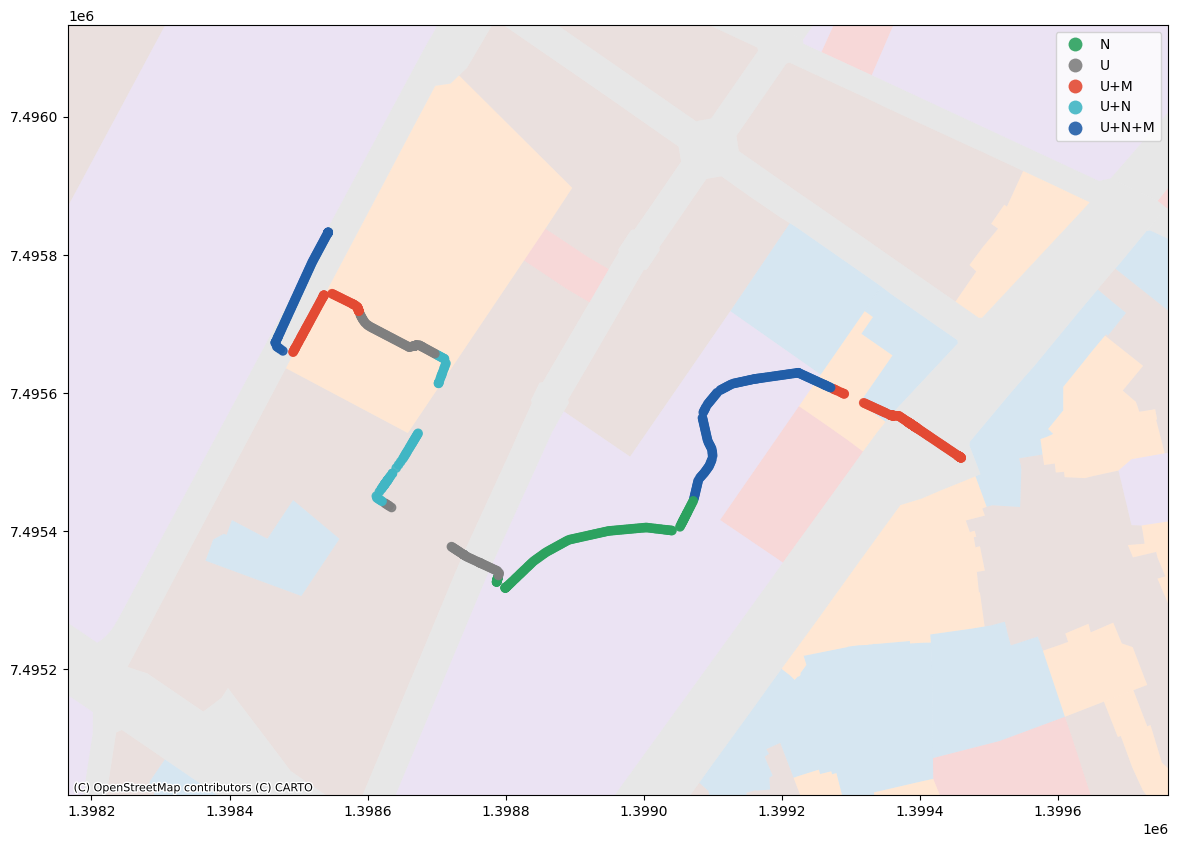

In [77]:
# project once
landuse_web = landuse.to_crs(epsg=3857)
gdf_web = gdf.to_crs(epsg=3857)

# -----------------------------
# LANDUSE BACKGROUND
# -----------------------------
landuse_web.plot(
    ax=ax,
    column="landuse_en",
    alpha=0.25,
    legend=True
)

fig, ax = plt.subplots(figsize=(15, 10))

# --------------------------------------------------
# BASEMAP (FIRST / UNDER EVERYTHING)
# --------------------------------------------------
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.6,
    zorder=0
)

# background polygons
landuse_web.plot(
    ax=ax,
    column="landuse_en",
    alpha=0.18,
    linewidth=0,
    legend=True
)

# participant typologies
gdf_web.plot(
    ax=ax,
    column="typologies",
    cmap=cmap,
    legend=True,
    markersize=35,
    alpha=0.9
)

# -----------------------------
# ZOOM TO PARTICIPANT
# -----------------------------
xmin, ymin, xmax, ymax = gdf_web.total_bounds

padding = 300

ax.set_xlim(xmin - padding, xmax + padding)
ax.set_ylim(ymin - padding, ymax + padding)